In [1]:
import importlib
import cg
import torch
import tests
from computational_graph import CG

---
# Computational Graphs (5 hours)

---

A **computational graph** is a directed acyclic graph (DAG) that represents a mathematical expression as a sequence of elementary operations. Each node in the graph corresponds to either:

- an **input variable** (leaf node),
- an **intermediate operation** (e.g. addition, multiplication, $\sin$, $\tanh$, …), or
- the **output** (root node) that produces the final result.
---

## How to use the graph builder

---

You build graphs using the `CG` class from `computational_graph.py`. Here is a minimal example:

```python
from computational_graph import CG

g = CG()

# 1. Define input nodes -- these are the input variables of your expression.
g.input("x", id="x", forward=2, backward=6)

# 2. Add intermediate operation nodes -- each references its parent node(s) by id.
g.add_node("²", id="x_sq", input_nodes=["x","other_id"], forward=4, backward=3)

# 3. Define exactly one output node.
g.output("*3", id="out", input_nodes=["x_sq"], forward=12, backward=1)
```

### Rules

| Rule | Details |
|---|---|
| **Node ids** | Every node needs a unique `id`. Input node ids **must match exactly** what the exercise description expects (e.g. `"x"`, `"y"`, `"z"`, `"W"`, `"V"`, `"b"`). |
| **`input_nodes`** | Each non-input node lists the `id`s of its parent nodes. Parents must already exist when you reference them, so add nodes in topological order. |
| **`forward`** | The value of the node after the forward pass. For scalars use plain numbers; for vectors/matrices use `torch.Tensor`. Round to 2 decimal places. |
| **`backward`** | The gradient after backpropagation. Round to 2 decimal places. |
| **One output** | Each graph must have **exactly one** output node (via `g.output(...)`). |

---

### Quick example

---

Here is a small demo graph that uses all three value types you will encounter in the exercises: a **scalar**, a **vector**, and a **matrix**.

We compute $f(a, \mathbf{v}, W) = a \cdot (W\mathbf{v})$ with:

$$a = 2,\quad \mathbf{v} = \begin{bmatrix}1\\3\end{bmatrix},\quad W = \begin{bmatrix}0.5 & 1.0\\2.0 & 0.5\end{bmatrix}$$

**Forward pass:**
- $W\mathbf{v} = \begin{bmatrix}3.5\\3.5\end{bmatrix}$
- $a \cdot W\mathbf{v} = \begin{bmatrix}7.0\\7.0\end{bmatrix}$

**Backward pass** (starting with $\frac{\partial f}{\partial f} = \begin{bmatrix}1\\1\end{bmatrix}$):

We won't compute all gradients here. The point is to see how the graph looks and how the API works. Run the cell below to visualize it.

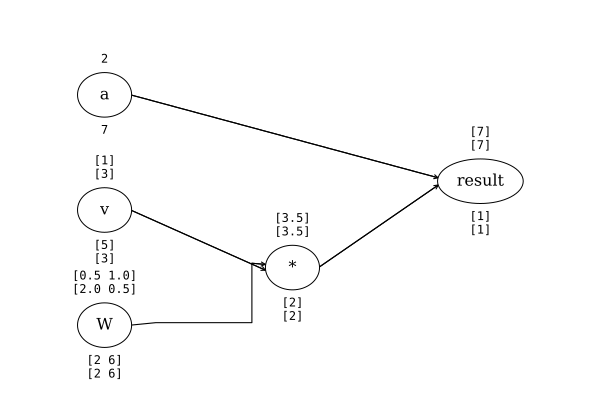

In [2]:
# --- Quick example: scalar, vector, and matrix inputs ---
g = CG()

# Input nodes: a scalar, a vector, and a matrix
g.input("a",  id="a", forward=2, backward=7.0)
g.input("v",  id="v", forward=torch.tensor([[1.0], [3.0]]),
                       backward=torch.tensor([[5.0], [3.0]]))
g.input("W",  id="W", forward=torch.tensor([[0.5, 1.0], [2.0, 0.5]]),
                       backward=torch.tensor([[2.0, 6.0], [2.0, 6.0]]))

# Intermediate node: matrix-vector product Wv
g.add_node("*", id="Wv", input_nodes=["W", "v"],
           forward=torch.tensor([[3.5], [3.5]]),
           backward=torch.tensor([[2.0], [2.0]]))

# Output node: scalar * vector  ->  a · (Wv)
g.output("result", id="out", input_nodes=["a", "Wv"],
         forward=torch.tensor([[7.0], [7.0]]),
         backward=torch.tensor([[1.0], [1.0]]))

g.render(show=True, figsize=(8, 5.5))

---

## Graph 1

---

Create the computational graph for the function $f$ and perform forward and backward propagation:

$$f(x,y,z) = ln(x/2)+3(xy)+sin(z)$$

Set $x=1,y=5,z=2.$

## **Task:**

Implement `graph_1` in `cg.py`.

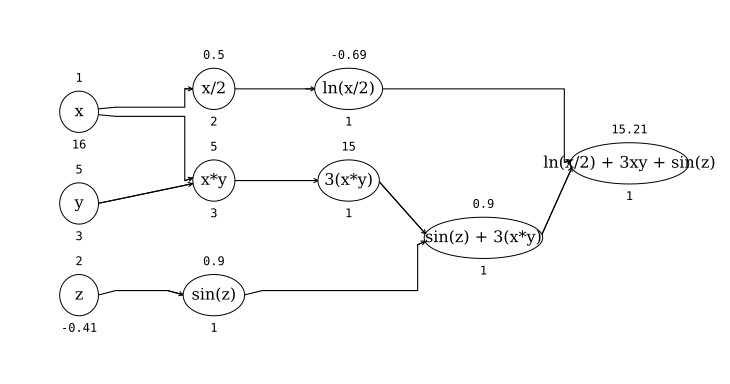

In [2]:
importlib.reload(cg)
cg.graph_1().render(show=True, figsize=(10, 5))

Test the correct forward and backward values for input and output nodes:

In [6]:
importlib.reload(tests)
importlib.reload(cg)
tests.test_graph_1()

Testing Graph 1:
  ✓ Correct number of input nodes (3)
  ✓ Input node 'x': correct shape and values
  ✓ Input node 'y': correct shape and values
  ✓ Input node 'z': correct shape and values
  ✓ Sufficient intermediate nodes (6 >= 6)
  ✓ Correct number of output nodes (1)
  ✓ Output node 'x7': correct shape and values

  All 7 checks passed! ✓


## Graph 2

Create the computational graph for the function $g$ and perform forward and backward propagation:
$$g(x,y,z) = \tanh(xy+z)*\cos(z)$$

Set $x=2,y=3,z=4.$

## **Task:**

Implement `graph_2` in `cg.py`.


**Hints:** 
- In the backward pass for $\tanh$, round very small values to 0.

In [25]:
import math
math.sin(4)


-0.7568024953079282

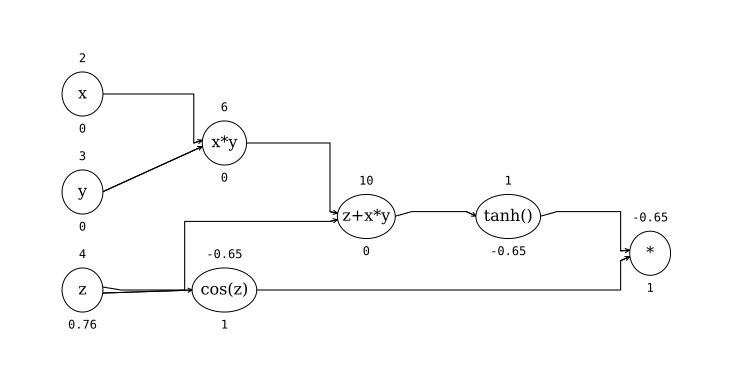

In [31]:
importlib.reload(cg)
cg.graph_2().render(show=True, figsize=(10, 5))


In [29]:
import math
math.sin(4)

-0.7568024953079282

Test the correct forward and backward values for input and output nodes:

In [30]:
importlib.reload(tests)
importlib.reload(cg)
tests.test_graph_2()

Testing Graph 2:
  ✓ Correct number of input nodes (3)
  ✓ Input node 'x': correct shape and values
  ✓ Input node 'y': correct shape and values
  ✓ Input node 'z': correct shape and values
  ✓ Sufficient intermediate nodes (4 >= 4)
  ✓ Correct number of output nodes (1)
  ✓ Output node 'x5': correct shape and values

  All 7 checks passed! ✓


---
## Graph 3

---

Create the computational graph for the function $h$ and perform forward and backward propagation: 

$$h(x,W,V,b)= V\sigma(Wx+b),$$

with $\sigma$ being the sigmoid function applied componentwise.

Set  $x=
\begin{bmatrix}
1 \\
2
\end{bmatrix}
$,
$W=
\begin{bmatrix}
0.10 & 0.05 \\
0.25 & 0.15 \\
0.10 & 0.40
\end{bmatrix}
$,
$b=
\begin{bmatrix}
0.10 \\
0.15 \\
0.20 
\end{bmatrix}
$
,
$V=
\begin{bmatrix}
1.00 & 0.50 & 0.20 
\end{bmatrix}
$.

## **Task:**

Implement `graph_3` in `cg.py`.

In [34]:
import math

def sigmoid(x):
    return 1 / (1 + math.exp(-x))

# Examples
sigmoid(1.1)    # 0.5
# ≈ 0.1192



0.7502601055951177

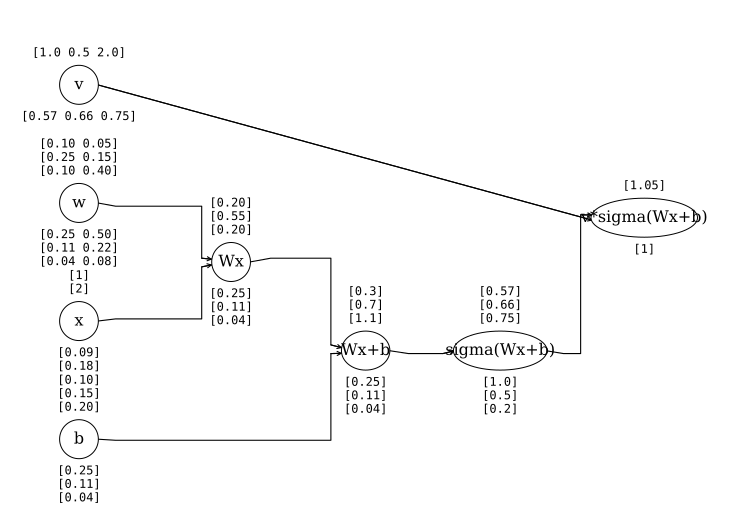

In [35]:
importlib.reload(cg)
cg.graph_3().render(show=True, figsize=(10, 7))

Test the correct forward and backward values for input and output nodes:

In [42]:
importlib.reload(tests)
importlib.reload(cg)
tests.test_graph_3()

Testing Graph 3:
  ✓ Correct number of input nodes (4)
  ✓ Input node 'W': correct shape and values
  ✓ Input node 'x': correct shape and values
  ✓ Input node 'b': correct shape and values
  ✓ Input node 'V': correct shape and values
  ✓ Sufficient intermediate nodes (3 >= 3)
  ✓ Correct number of output nodes (1)
  ✓ Output node 'x4': correct shape and values

  All 8 checks passed! ✓


---
## Graph 4

---

Create the computational graph for the function $i$ and perform forward and backward propagation:

$$i(x,y,W,V) = \frac{1}{2}|| y - \text{ReLU}(x^TW)V ||^2_2$$

Set  $x=
\begin{bmatrix}
1 \\
2
\end{bmatrix}
$,
$y = 3$,
$W=
\begin{bmatrix}
0.50 & 0.25 \\
0.20 & -0.40
\end{bmatrix}
$,
$V=
\begin{bmatrix}
3.00 \\
2.00 
\end{bmatrix}
$.

## **Task:**

Implement `graph_4` in `cg.py`.

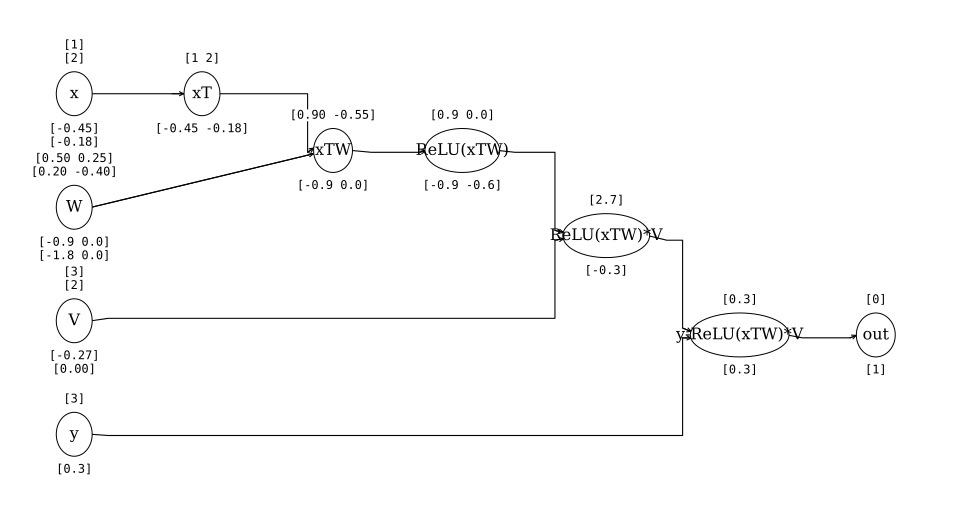

In [43]:
importlib.reload(cg)
cg.graph_4().render(show=True, figsize=(13, 7)) 

Test the correct forward and backward values for input and output nodes:

In [45]:
importlib.reload(tests)
importlib.reload(cg)
tests.test_graph_4()

Testing Graph 4:
  ✓ Correct number of input nodes (4)
  ✓ Input node 'x': correct shape and values
  ✓ Input node 'W': correct shape and values
  ✓ Input node 'V': correct shape and values
  ✓ Input node 'y': correct shape and values
  ⚠ WARNING: Expected at least 6 intermediate node(s), got 5. Your graph might be missing steps.
  ✓ Correct number of output nodes (1)
  ✓ Output node 'x6': correct shape and values

  All 7 checks passed! ✓


d:\Deep Learning\exercises\03-exercises\03a-computational-graphs\tests.py:124: UserWarning:   ⚠ Expected at least 6 intermediate node(s), got 5. Your graph might be missing steps.
  warnings.warn(
